# CTC Sales Forecasting with a Direct-Prompting LLMP

This notebook follows the direct-prompting approach from `02_intro_agentic_predictor.ipynb`. `SampledTrajectoryLLMPredictor` sends the CTC sales history to Gemini and turns multiple sampled trajectories into probabilistic forecasts. No search tools or code-execution tools are used.

## 1. Imports, model configuration, and data paths

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv

from aieng.forecasting.data import DataService, SeriesMetadata
from aieng.forecasting.data.features import StaticFrameAdapter
from aieng.forecasting.evaluation.task import ForecastingTask
from aieng.forecasting.methods import (
    SampledTrajectoryLLMPredictor,
    SampledTrajectoryLLMPredictorConfig,
)

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "CTC":
    CTC_ROOT = REPO_ROOT
else:
    CTC_ROOT = REPO_ROOT / "implementations" / "CTC"

load_dotenv(REPO_ROOT / ".env", override=False)

TRAIN_PATH = CTC_ROOT / "data" / "processed" / "ctc_train.parquet"
TEST_PATH = CTC_ROOT / "data" / "processed" / "ctc_test.parquet"
SALES_SERIES_ID = "ctc_sales"
FREQUENCY = "W-MON"
MODEL = "gemini-3.1-flash-lite-preview"
N_SAMPLES = 20
HISTORY_WINDOW = None
RUN_LLM = True

print(f"Model: {MODEL}")
print(f"Samples per forecast: {N_SAMPLES}")
print(f"Run LLM calls: {RUN_LLM}")

Model: gemini-3.1-flash-lite-preview
Samples per forecast: 20
Run LLM calls: True


## 2. Load the CTC train and test splits

In [2]:
train_df = pd.read_parquet(TRAIN_PATH)
test_df = pd.read_parquet(TEST_PATH)

for name, frame in {"train": train_df, "test": test_df}.items():
    required = {"timestamp", "value"}
    missing = required.difference(frame.columns)
    if missing:
        raise ValueError(f"{name} data is missing columns: {sorted(missing)}")
    frame["timestamp"] = pd.to_datetime(frame["timestamp"], utc=True).dt.tz_localize(None)
    frame["value"] = pd.to_numeric(frame["value"], errors="raise").astype(float)

train_df = train_df.sort_values("timestamp").reset_index(drop=True)
test_df = test_df.sort_values("timestamp").reset_index(drop=True)

train_end = train_df["timestamp"].max()
test_start = test_df["timestamp"].min()
gap_steps = (test_start - train_end).days // 7
test_steps = len(test_df)
test_horizons = list(range(gap_steps, gap_steps + test_steps))

print(f"Train: {len(train_df)} rows, ending {train_end.date()}")
print(f"Test:  {len(test_df)} rows, starting {test_start.date()}")
print(f"Gap:   {gap_steps} weekly steps")
print(f"LLMP horizons: {test_horizons[0]} through {test_horizons[-1]}")
display(train_df.head())
display(test_df.head())

Train: 191 rows, ending 2023-08-28
Test:  42 rows, starting 2024-06-17
Gap:   42 weekly steps
LLMP horizons: 42 through 83


,timestamp,value,released_at,timestamp_year,timestamp_month,timestamp_day,timestamp_day_of_week
0,2020-01-06,143.0,2020-01-12 00:00:00+00:00,2020,1,6,0
1,2020-01-13,174.0,2020-01-19 00:00:00+00:00,2020,1,13,0
2,2020-01-20,148.0,2020-01-26 00:00:00+00:00,2020,1,20,0
3,2020-01-27,141.0,2020-02-02 00:00:00+00:00,2020,1,27,0
4,2020-02-03,156.0,2020-02-09 00:00:00+00:00,2020,2,3,0


,timestamp,value,released_at,timestamp_year,timestamp_month,timestamp_day,timestamp_day_of_week
0,2024-06-17,124.0,2024-06-23 00:00:00+00:00,2024,6,17,0
1,2024-06-24,163.0,2024-06-30 00:00:00+00:00,2024,6,24,0
2,2024-07-01,160.0,2024-07-07 00:00:00+00:00,2024,7,1,0
3,2024-07-08,143.0,2024-07-14 00:00:00+00:00,2024,7,8,0
4,2024-07-15,157.0,2024-07-21 00:00:00+00:00,2024,7,15,0


## 3. Register the training history with a cutoff-safe DataService

The full CSV is registered, but every row is released on its observation date. The context cutoff is the last training timestamp, so the predictor sees training history only and never sees the test values.

In [3]:
all_df = pd.concat([train_df, test_df], ignore_index=True).sort_values("timestamp")
all_df["released_at"] = all_df["timestamp"]
canonical_sales = all_df[["timestamp", "value", "released_at"]].reset_index(drop=True)

data_service = DataService()
data_service.register(
    SALES_SERIES_ID,
    StaticFrameAdapter(canonical_sales),
    SeriesMetadata(
        series_id=SALES_SERIES_ID,
        description="CTC weekly sales",
        source="forecasting_sales_ctc.csv",
        units="sales units",
        frequency=FREQUENCY,
    ),
)

ctx = data_service.context(as_of=train_end)
visible_history = ctx.get_series(SALES_SERIES_ID)

print(f"Rows visible to the LLMP: {len(visible_history)}")
print(f"Last visible timestamp: {visible_history['timestamp'].max().date()}")
assert len(visible_history) == len(train_df)
assert visible_history["timestamp"].max() == train_end

Rows visible to the LLMP: 191
Last visible timestamp: 2023-08-28


## 4. Define the forecasting task and LLMP configuration

In [4]:
task = ForecastingTask(
task_id="ctc_sales_llmp_test_forecast",
target_series_id=SALES_SERIES_ID,
horizons=test_horizons,
frequency=FREQUENCY,
description=(
    "Forecast weekly supplement sales. The first forecast date is the test-set start; "
    "produce one value for every weekly test observation."
),
)

llmp_config = SampledTrajectoryLLMPredictorConfig(
model=MODEL,
n_samples=N_SAMPLES,
history_window=HISTORY_WINDOW,
precision=2,
series_description=(
    "Series: CTC weekly sales.\n"
    "Units: sales units.\n"
    "Frequency: weekly, with weeks starting on Monday."
),
user_prompt_suffix=(
    "Values are non-negative sales counts. Preserve non-negativity. "
    "Use recent level, trend, and recurring weekly behavior when projecting."
),
variant_tag="ctc_sales_test_v1",
)

predictor = SampledTrajectoryLLMPredictor(llmp_config)
print(f"Task horizons: {task.horizons[0]}..{task.horizons[-1]} ({len(task.horizons)} predictions)")
print(f"Predictor: {predictor.predictor_id}")

Task horizons: 42..83 (42 predictions)
Predictor: llmp_sampled_trajectories_ctc_sales_test_v1[gemini-3.1-flash-lite-preview]


## 5. Inspect the direct prompt before calling Gemini

In [5]:
from aieng.forecasting.methods.llm_processes.sampled_trajectory import (
    _build_user_prompt,
)
from aieng.forecasting.methods.llm_processes.base import serialize_history

history_text = serialize_history(visible_history, precision=llmp_config.precision)
prompt_start = _build_user_prompt(
    task,
    history_text,
    data_service.get_metadata(SALES_SERIES_ID),
    pd.Timestamp(train_end) + pd.tseries.frequencies.to_offset(FREQUENCY),
    pd.Timestamp(train_end) + pd.tseries.frequencies.to_offset(FREQUENCY) * task.horizon,
    task.horizon,
    series_description_override=llmp_config.series_description,
    suffix=llmp_config.user_prompt_suffix,
)
print(prompt_start[:2500])
print("\n...[prompt truncated]...")

Task: Forecast weekly supplement sales. The first forecast date is the test-set start; produce one value for every weekly test observation.

Series: CTC weekly sales.
Units: sales units.
Frequency: weekly, with weeks starting on Monday.

History:
2020-01-06: 143.00
2020-01-13: 174.00
2020-01-20: 148.00
2020-01-27: 141.00
2020-02-03: 156.00
2020-02-10: 162.00
2020-02-17: 117.00
2020-02-24: 147.00
2020-03-02: 151.00
2020-03-09: 132.00
2020-03-16: 136.00
2020-03-23: 143.00
2020-03-30: 140.00
2020-04-06: 147.00
2020-04-13: 162.00
2020-04-20: 141.00
2020-04-27: 142.00
2020-05-04: 157.00
2020-05-11: 156.00
2020-05-18: 145.00
2020-05-25: 149.00
2020-06-01: 155.00
2020-06-08: 142.00
2020-06-15: 144.00
2020-06-22: 147.00
2020-06-29: 156.00
2020-07-06: 146.00
2020-07-13: 149.00
2020-07-20: 143.00
2020-07-27: 146.00
2020-08-03: 155.00
2020-08-10: 171.00
2020-08-17: 147.00
2020-08-24: 146.00
2020-08-31: 151.00
2020-09-07: 142.00
2020-09-14: 144.00
2020-09-21: 159.00
2020-09-28: 151.00
2020-10-05: 

## 6. Call Gemini through the repository LLMP predictor

In [6]:
if not RUN_LLM:
    print("RUN_LLM is False. Set it to True to call Gemini.")
else:
    predictions = predictor.predict(task, ctx)
    print(f"Received {len(predictions)} forecasts.\n")
    for horizon, prediction in zip(task.horizons, predictions):
        forecast = prediction.payload
        print(
            f"h={horizon:>2}  date={prediction.forecast_date.date()}  "
            f"point={forecast.point_forecast:.2f}  "
            f"p10={forecast.quantiles[0.10]:.2f}  "
            f"p90={forecast.quantiles[0.90]:.2f}"
        )

Received 42 forecasts.

h=42  date=2024-06-17  point=150.00  p10=146.89  p90=155.01
h=43  date=2024-06-24  point=149.00  p10=145.90  p90=154.23
h=44  date=2024-07-01  point=148.00  p10=145.80  p90=157.83
h=45  date=2024-07-08  point=147.50  p10=143.60  p90=152.71
h=46  date=2024-07-15  point=147.50  p10=145.00  p90=153.75
h=47  date=2024-07-22  point=149.00  p10=145.97  p90=155.40
h=48  date=2024-07-29  point=149.30  p10=144.00  p90=156.40
h=49  date=2024-08-05  point=149.45  p10=143.63  p90=156.60
h=50  date=2024-08-12  point=149.00  p10=145.90  p90=156.80
h=51  date=2024-08-19  point=148.05  p10=145.00  p90=159.60
h=52  date=2024-08-26  point=149.50  p10=145.96  p90=154.00
h=53  date=2024-09-02  point=148.50  p10=143.70  p90=154.70
h=54  date=2024-09-09  point=150.00  p10=146.70  p90=156.60
h=55  date=2024-09-16  point=149.05  p10=144.61  p90=157.70
h=56  date=2024-09-23  point=148.50  p10=145.00  p90=158.80
h=57  date=2024-09-30  point=148.70  p10=145.00  p90=158.00
h=58  date=2024-

## 7. Align LLMP forecasts with the test set and evaluate

In [7]:
if RUN_LLM:
    forecast_df = pd.DataFrame(
        {
            "timestamp": [p.forecast_date for p in predictions],
            "forecast": [p.payload.point_forecast for p in predictions],
            "p10": [p.payload.quantiles[0.10] for p in predictions],
            "p90": [p.payload.quantiles[0.90] for p in predictions],
        }
    )
    forecast_df["timestamp"] = pd.to_datetime(forecast_df["timestamp"]).dt.tz_localize(None)
    evaluation = test_df[["timestamp", "value"]].merge(
        forecast_df, on="timestamp", how="left", validate="one_to_one"
    )
    if evaluation["forecast"].isna().any():
        raise ValueError("Some LLMP forecast dates did not match the test dates.")

    actual = evaluation["value"].to_numpy(dtype=float)
    predicted = evaluation["forecast"].to_numpy(dtype=float)
    errors = predicted - actual
    nonzero = actual != 0
    metrics = pd.Series(
        {
            "MAE": np.mean(np.abs(errors)),
            "RMSE": np.sqrt(np.mean(errors**2)),
            "MAPE (%)": np.mean(np.abs(errors[nonzero] / actual[nonzero])) * 100,
        },
        name="LLMP test metrics",
    )
    display(evaluation.head())
    display(metrics.to_frame())

,timestamp,value,forecast,p10,p90
0,2024-06-17,124.0,150.0,146.89,155.01
1,2024-06-24,163.0,149.0,145.90,154.23
2,2024-07-01,160.0,148.0,145.80,157.83
3,2024-07-08,143.0,147.5,143.60,152.71
4,2024-07-15,157.0,147.5,145.00,153.75


,LLMP test metrics
MAE,10.811905
RMSE,13.557036
MAPE (%),7.194831


## 8. Plot the LLMP test forecast

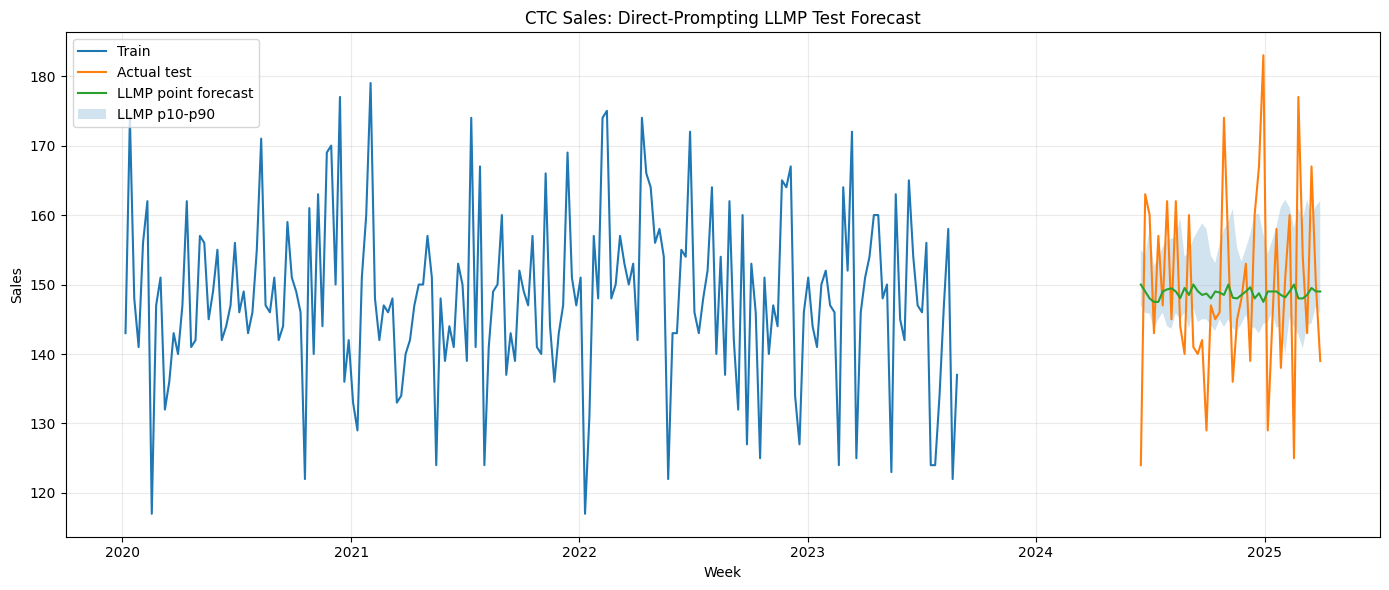

In [8]:
if RUN_LLM:
    plt.figure(figsize=(14, 6))
    plt.plot(train_df["timestamp"], train_df["value"], label="Train")
    plt.plot(test_df["timestamp"], test_df["value"], label="Actual test")
    plt.plot(forecast_df["timestamp"], forecast_df["forecast"], label="LLMP point forecast")
    plt.fill_between(
        forecast_df["timestamp"],
        forecast_df["p10"],
        forecast_df["p90"],
        alpha=0.2,
        label="LLMP p10-p90",
    )
    plt.title("CTC Sales: Direct-Prompting LLMP Test Forecast")
    plt.xlabel("Week")
    plt.ylabel("Sales")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()

## Notes

`SampledTrajectoryLLMPredictor` makes `N_SAMPLES` separate Gemini completions and computes empirical quantiles across the returned trajectories. Set `RUN_LLM = False` while inspecting or editing the notebook; set it to `True` only when `OPENAI_BASE_URL` and `OPENAI_API_KEY` are available through the repository `.env`. The model is asked to forecast through the train-to-test gap, and horizons 42 through 83 correspond exactly to the 42 weekly test observations.